# 실습 4-2 : Under/Over Sampling (AI4I 데이터 버전)

#### **<실습 내용>**

1. 클래스 불균형 데이터 확인
- t-SNE를 통한 시각화

2. Resampling 기법 적용
- Random Undersampling
- TomekLinks (Undersampling)
- SMOTE (Oversampling)
- SMOTE + TomekLinks (복합 Resampling)
- ADASYN (Oversampling)

3. Resampling 전후 T-SNE 및 성능 비교

## 분석 준비

### 주요 라이브러리 호출

In [1]:
# 실행해서 설치해주세요.
! pip install imbalanced-learn

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.manifold import TSNE

from imblearn.under_sampling import TomekLinks, RandomUnderSampler
from imblearn.over_sampling import SMOTE, ADASYN, RandomOverSampler
from imblearn.combine import SMOTETomek

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

### 데이터 불러오기

In [3]:
data = pd.read_csv("dataset/day4-2_data.csv")

# 고장 유형 컬럼(TWF~RNF)은 Machine failure 여부와 직접 연관되어 정보 누수가 발생하므로 제거
data = data.drop(columns=["TWF", "HDF", "PWF", "OSF", "RNF"])

# Type(범주형)은 원-핫 인코딩
data = pd.get_dummies(data, columns=["Type"], drop_first=True)

print("데이터 크기:", data.shape)
print("결측치 수:", data.isnull().sum().sum())
data.head()

데이터 크기: (10000, 8)
결측치 수: 0


,Air temperature,Process temperature,Rotational speed,Torque,Tool wear,Machine failure,Type_L,Type_M
0,298.1,308.6,1551,42.8,0,0,False,True
1,298.2,308.7,1408,46.3,3,0,True,False
2,298.1,308.5,1498,49.4,5,0,True,False
3,298.2,308.6,1433,39.5,7,0,True,False
4,298.2,308.7,1408,40.0,9,0,True,False


---

## 1) 클래스 불균형 확인

> **클래스 불균형(Class Imbalance)** 이란 정상 데이터의 양이 불량 데이터보다 훨씬 많은 상황을 의미함
> - 해결 기법: **Resampling** (Under/Over Sampling) 또는 **One-Class Learning Model**

In [4]:
X = data.drop(["Machine failure"], axis=1)  # 타겟 컬럼 제외한 나머지를 입력 변수로 사용
Y = data["Machine failure"]

In [5]:
print("클래스 분포:")
print(Y.value_counts())  # 클래스별 개수 확인

클래스 분포:
Machine failure
0    9661
1     339
Name: count, dtype: int64


In [6]:
print("클래스 비율:")
print(np.round(Y.value_counts(normalize=True), 3))  # 클래스별 비율 확인 (소수점 3자리)

클래스 비율:
Machine failure
0    0.966
1    0.034
Name: proportion, dtype: float64


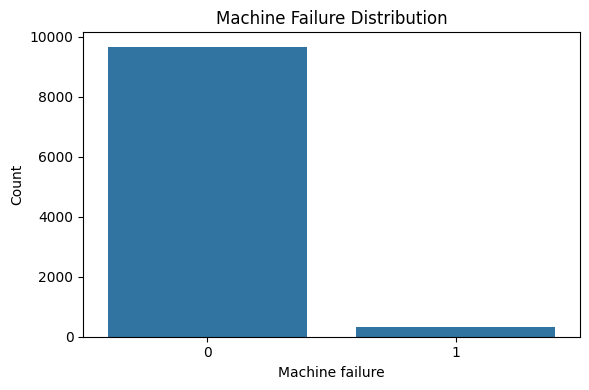

In [7]:
# 클래스 분포 시각화
plt.figure(figsize=(6, 4))
sns.barplot(x=Y.value_counts().index, y=Y.value_counts().values)  # 클래스별 개수를 막대그래프로 표시
plt.title("Machine Failure Distribution")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

### 1-1) t-SNE를 통한 시각화

> **t-SNE**는 고차원 데이터를 2차원으로 매핑하여 시각화하는 기법임
> - 클래스 간 분리 정도를 시각적으로 확인할 수 있음
> - 분리가 잘 될수록 분류 모델이 두 클래스를 구분하기 쉬운 데이터라는 뜻임

In [8]:
# n_components=2 : 원래 수백 개 특성을 가진 데이터를 2차원 좌표(x, y)로 압축
# fit_transform(X) : X를 학습하면서 동시에 2차원 좌표로 변환

X_embedded = TSNE(n_components=2, random_state=42).fit_transform(X)
X_embedded

array([[ 19.73424  , -61.158875 ],
       [-61.846077 , -55.196808 ],
       [ -6.1263146, -66.062004 ],
       ...,
       [ 53.29652  , -37.41317  ],
       [-53.81907  , -48.92215  ],
       [ -4.4799647, -56.61547  ]], dtype=float32)

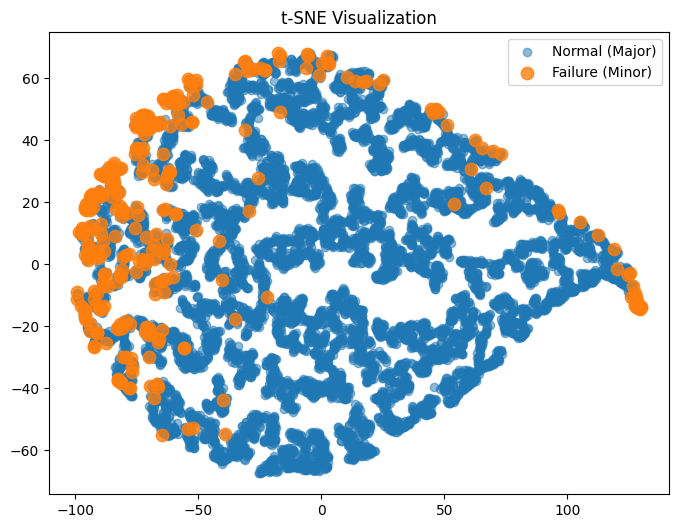

In [9]:
plt.figure(figsize=(8, 6))
# X_embedded[Y == 0, 0] : Normal 클래스(Y=0)의 x좌표, X_embedded[Y == 0, 1] : y좌표
plt.scatter(X_embedded[Y == 0, 0], X_embedded[Y == 0, 1], label='Normal (Major)', alpha=0.5)  # 다수 클래스(정상) 산점도
# X_embedded[Y == 1, 0] : Failure 클래스(Y=1)의 x좌표, X_embedded[Y == 1, 1] : y좌표
plt.scatter(X_embedded[Y == 1, 0], X_embedded[Y == 1, 1], label='Failure (Minor)', alpha=0.8, s=80)  # 소수 클래스(고장) 산점도, 점 크기 크게
plt.legend()
plt.title("t-SNE Visualization")
plt.show()

---

## 2) Resampling 기법 적용

| 기법 | 유형 | 설명 |
|---|---|---|
| TomekLinks | Undersampling | 서로 다른 클래스끼리 너무 가까이 붙어있는 다수 클래스 샘플을 제거함 |
| SMOTE | Oversampling | 소수 클래스 샘플들 사이를 보간해서 새로운 가상 샘플을 만들어냄 |
| SMOTE + TomekLinks | 복합 Resampling | SMOTE로 소수 클래스를 늘린 뒤, TomekLinks로 애매하게 겹치는 샘플을 정리함 |
| ADASYN | Oversampling | SMOTE와 비슷하지만 구분이 어려운 샘플 주변에 더 많은 가상 샘플을 만들어냄 |

> Resampling은 **학습 데이터에만** 적용하고, 테스트 데이터는 원본 그대로 유지해야 함

In [10]:
# test는 실제 환경과 동일한 불균형 상태를 유지해야 모델 성능을 제대로 평가할 수 있음

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)
print("학습 데이터 클래스 분포:")
print(Y_train.value_counts())

학습 데이터 클래스 분포:
Machine failure
0    7729
1     271
Name: count, dtype: int64


### 2-1) TomekLinks (Undersampling)

> **Tomek Links**는 서로 다른 클래스끼리 너무 가까이 붙어있는 다수 클래스 샘플을 제거함

In [11]:
X_TomekLinks, Y_TomekLinks = TomekLinks().fit_resample(X_train, Y_train)  # TomekLinks로 다수 클래스 일부 제거 (undersampling)

# 적용 전/후 클래스별 개수 비교
compare_TL = pd.DataFrame({"적용 전": Y_train.value_counts(), "적용 후": Y_TomekLinks.value_counts()})
compare_TL["변화"] = compare_TL["적용 후"] - compare_TL["적용 전"]  # 클래스별 변화량 계산
compare_TL

,적용 전,적용 후,변화
Machine failure,,,
0,7729,7641,-88
1,271,271,0


### 2-2) SMOTE (Oversampling)

> **SMOTE**는 소수 클래스 샘플들 사이를 보간해서 새로운 가상 샘플을 만들어냄

In [12]:
X_SMOTE, Y_SMOTE = SMOTE().fit_resample(X_train, Y_train)  # SMOTE로 소수 클래스를 다수 클래스 수만큼 늘림 (oversampling)

# 적용 전/후 클래스별 개수 비교
compare_SMOTE = pd.DataFrame({"적용 전": Y_train.value_counts(), "적용 후": Y_SMOTE.value_counts()})
compare_SMOTE["변화"] = compare_SMOTE["적용 후"] - compare_SMOTE["적용 전"]  # 클래스별 변화량 계산
compare_SMOTE

,적용 전,적용 후,변화
Machine failure,,,
0,7729,7729,0
1,271,7729,7458


### 2-3) SMOTE + TomekLinks (복합 Resampling)

> SMOTE로 소수 클래스를 늘린 뒤, TomekLinks로 애매하게 겹치는 샘플을 정리함

In [13]:
X_SMOTETomek, Y_SMOTETomek = SMOTETomek().fit_resample(X_train, Y_train)  # SMOTE로 늘린 뒤 TomekLinks로 겹치는 샘플 정리 (복합 resampling)

# 적용 전/후 클래스별 개수 비교
compare_SMOTE_TL = pd.DataFrame({"적용 전": Y_train.value_counts(), "적용 후": Y_SMOTETomek.value_counts()})
compare_SMOTE_TL["변화"] = compare_SMOTE_TL["적용 후"] - compare_SMOTE_TL["적용 전"]  # 클래스별 변화량 계산
compare_SMOTE_TL

,적용 전,적용 후,변화
Machine failure,,,
0,7729,7649,-80
1,271,7649,7378


### 2-4) ADASYN (Oversampling)

> **ADASYN**은 SMOTE를 개선한 기법으로, 다수 클래스와 인접한 소수 클래스 샘플 주변에 더 많은 데이터를 생성함
> - 즉 분류가 어려운 경계 영역에 집중적으로 데이터를 증강함

In [14]:
X_ADASYN, Y_ADASYN = ADASYN(random_state=42).fit_resample(X_train, Y_train)  # ADASYN으로 소수 클래스를 다수 클래스 수만큼 늘림 (경계 근처에 더 많이 생성)

# 적용 전/후 클래스별 개수 비교
compare_ADA = pd.DataFrame({"적용 전": Y_train.value_counts(), "적용 후": Y_ADASYN.value_counts()})
compare_ADA["변화"] = compare_ADA["적용 후"] - compare_ADA["적용 전"]  # 클래스별 변화량 계산
compare_ADA

,적용 전,적용 후,변화
Machine failure,,,
0,7729,7729,0
1,271,7671,7400


> 기본 설정 기준: `sampling_strategy ='auto'`
> - 1:1이 되는 기법: SMOTE, SMOTE+TomekLinks
> - 1:1이 아닌 기법: TomekLinks (다수 클래스 일부만 제거), ADASYN (경계 근처 위주로 생성되어 정확히 1:1은 아님)

---

## 3) Resampling 결과 분석

### 3-1) Sampling 전후 t-SNE 비교

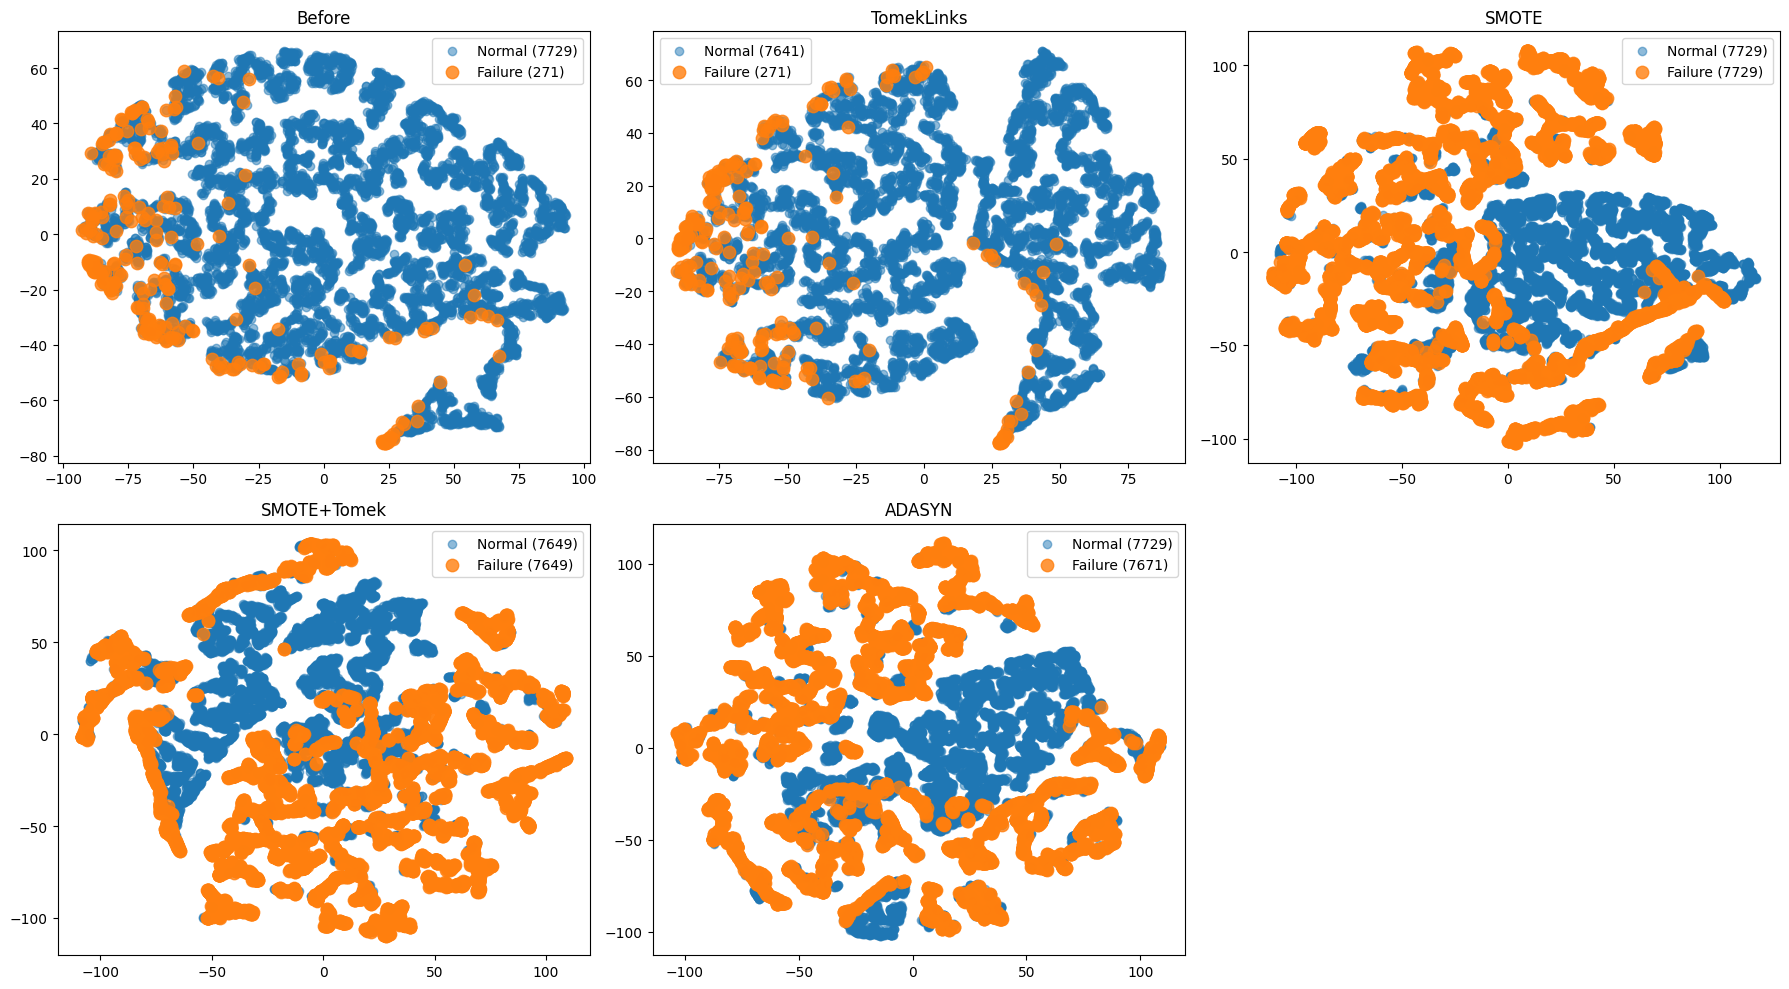

In [15]:
# 방법론별 t-SNE 비교 (Normal vs Failure)
A, B = 0, 1  # Normal, Failure

sampling_datasets = {
    "Before": (X_train, Y_train),
    "TomekLinks": (X_TomekLinks, Y_TomekLinks),
    "SMOTE": (X_SMOTE, Y_SMOTE),
    "SMOTE+Tomek": (X_SMOTETomek, Y_SMOTETomek),
    "ADASYN": (X_ADASYN, Y_ADASYN),
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (name, (X_s, Y_s)) in enumerate(sampling_datasets.items()):
    emb = TSNE(n_components=2, init='random', learning_rate='auto', perplexity=30, random_state=42).fit_transform(X_s)
    axes[i].scatter(emb[Y_s.values == A, 0], emb[Y_s.values == A, 1], label=f'Normal ({(Y_s==A).sum()})', alpha=0.5)
    axes[i].scatter(emb[Y_s.values == B, 0], emb[Y_s.values == B, 1], label=f'Failure ({(Y_s==B).sum()})', alpha=0.8, s=80)
    axes[i].set_title(name)
    axes[i].legend()

axes[-1].axis("off")
plt.tight_layout()
plt.show()

### 3-2) Sampling 전후 성능 비교

In [16]:
from xgboost import XGBClassifier

results = []
for name, (X_tr, Y_tr) in sampling_datasets.items():

    neg, pos = (Y_tr == 0).sum(), (Y_tr == 1).sum()
    scale_pos_weight = neg / pos  # 불균형 비율 반영

    xgb = XGBClassifier(
        n_estimators=100,
        max_depth=6,
        scale_pos_weight=scale_pos_weight,
        random_state=42
    )
    xgb.fit(X_tr, Y_tr)
    pred = xgb.predict(X_test)
    results.append({
        "Method": name,
        "Precision": round(precision_score(Y_test, pred, pos_label=1), 4),
        "Recall": round(recall_score(Y_test, pred, pos_label=1), 4),
        "F1-score": round(f1_score(Y_test, pred, pos_label=1), 4)
    })

pd.DataFrame(results)

,Method,Precision,Recall,F1-score
0,Before,0.7027,0.7647,0.7324
1,TomekLinks,0.7432,0.8088,0.7746
2,SMOTE,0.5714,0.7647,0.6541
3,SMOTE+Tomek,0.5532,0.7647,0.6420
4,ADASYN,0.5400,0.7941,0.6429


---

## 4) Vibe Coding 실습

**[과제 1]**
지수는 위 t-SNE 시각화 결과(Before / TomekLinks / SMOTE / SMOTE+Tomek / ADASYN)를 보고, Resampling 기법마다 Normal과 Failure 클래스가 어떻게 다르게 분포하는지 궁금해졌습니다.

AI에게 이미지를 보여주며 각 기법의 결과가 어떤 의미를 갖는지 해석을 요청하고 원본 데이터에서 Failure 데이터가 339개(전체의 3.4%)뿐이라는 점을 함께 고려했을 때 이 문제에는 Resampling과 One-Class Learning 중 어떤 접근이 더 적합할지 AI와 논의해 보세요.

In [17]:
# [과제 1] t-SNE 해석 + Resampling vs One-Class Learning 논의

# --- 1) 클래스 불균형 현황 ---
total_n = len(Y)
fail_n = (Y == 1).sum()
print("=== 데이터 불균형 현황 ===")
print(f"전체: {total_n:,}개 | Failure: {fail_n}개 ({fail_n / total_n * 100:.1f}%)")
print(f"학습(train) Failure: {(Y_train == 1).sum()}개 / {(Y_train == 0).sum()}개 Normal")

# --- 2) Resampling 기법별 t-SNE 해석 ---
tsne_interpretation = {
    "Before": (
        "Failure(빨강) 점이 Normal(파랑)에 비해 매우 적고, Normal 영역 안·경계에 흩어져 있음. "
        "소수 클래스가 다수 클래스에 묻혀 보이는 전형적인 불균형 분포."
    ),
    "TomekLinks": (
        "서로 다른 클래스가 너무 가까운 Normal(다수) 샘플을 제거해 경계가 조금 정리됨. "
        "Failure 수는 그대로, Normal만 소폭 감소 → 겹치는 영역이 줄어듦."
    ),
    "SMOTE": (
        "Failure 점이 크게 늘어남. 기존 Failure 샘플 사이를 보간한 가상 점이 채워져 "
        "두 클래스 비율이 1:1에 가깝게 보임. Normal 덩어리 사이에 Failure 군집이 확장됨."
    ),
    "SMOTE+Tomek": (
        "SMOTE로 Failure를 늘린 뒤, 경계에서 애매하게 겹치는 점을 TomekLinks로 정리. "
        "SMOTE만 적용했을 때보다 클래스 경계가 상대적으로 깔끔해짐."
    ),
    "ADASYN": (
        "SMOTE와 비슷하게 Failure가 늘지만, 다수 클래스와 가까운(분류 어려운) "
        "경계 부근에 더 많은 가상 샘플이 생성됨. 어려운 구간에 Failure가 집중되는 경향."
    ),
}

print("\n=== t-SNE 기법별 해석 ===")
for name, desc in tsne_interpretation.items():
    x_s, y_s = sampling_datasets[name]
    print(f"\n[{name}]  Normal={ (y_s == 0).sum():,}  Failure={ (y_s == 1).sum():,}")
    print(f"  → {desc}")

# --- 3) 성능 비교 (Section 3-2 결과 재확인) ---
print("\n=== Resampling 후 XGBoost 성능 (test 기준) ===")
print(pd.DataFrame(results).to_string(index=False))

# --- 4) Resampling vs One-Class Learning 논의 ---
discussion = """
=== Resampling vs One-Class Learning ===

[One-Class Learning이 고려되는 이유]
  - Failure가 3.4%로 매우 적어, '정상만 학습하고 이상을 탐지'하는 접근이 가능함.

[이 데이터에서는 Resampling이 더 적합한 이유]
  1) Failure 라벨이 339개(학습 약 271개)로 존재 → 지도학습 + Resampling이 가능한 수준.
  2) One-Class는 라벨된 Failure 정보를 거의 쓰지 않음 → 이미 있는 고장 데이터를 활용 못 함.
  3) 실습 결과: TomekLinks(F1≈0.77)가 SMOTE/ADASYN(F1≈0.64)보다 우수.
     → 무조건 Oversampling이 좋은 것은 아니며, 경계 정리(Under)가 더 효과적일 수 있음.

[정리]
  - 1차 추천: Resampling (특히 TomekLinks 또는 scale_pos_weight 병행) + F1 기준 평가
  - One-Class Learning: Failure 라벨이 극히 적거나(수십 개 미만),
    '미지의 이상 탐지'가 목표일 때 보조적으로 고려.
"""
print(discussion)
print("최종 선택: Resampling (Failure 라벨 339개 활용 가능 + 실습 성능 우위)")


=== 데이터 불균형 현황 ===
전체: 10,000개 | Failure: 339개 (3.4%)
학습(train) Failure: 271개 / 7729개 Normal

=== t-SNE 기법별 해석 ===

[Before]  Normal=7,729  Failure=271
  → Failure(빨강) 점이 Normal(파랑)에 비해 매우 적고, Normal 영역 안·경계에 흩어져 있음. 소수 클래스가 다수 클래스에 묻혀 보이는 전형적인 불균형 분포.

[TomekLinks]  Normal=7,641  Failure=271
  → 서로 다른 클래스가 너무 가까운 Normal(다수) 샘플을 제거해 경계가 조금 정리됨. Failure 수는 그대로, Normal만 소폭 감소 → 겹치는 영역이 줄어듦.

[SMOTE]  Normal=7,729  Failure=7,729
  → Failure 점이 크게 늘어남. 기존 Failure 샘플 사이를 보간한 가상 점이 채워져 두 클래스 비율이 1:1에 가깝게 보임. Normal 덩어리 사이에 Failure 군집이 확장됨.

[SMOTE+Tomek]  Normal=7,649  Failure=7,649
  → SMOTE로 Failure를 늘린 뒤, 경계에서 애매하게 겹치는 점을 TomekLinks로 정리. SMOTE만 적용했을 때보다 클래스 경계가 상대적으로 깔끔해짐.

[ADASYN]  Normal=7,729  Failure=7,671
  → SMOTE와 비슷하게 Failure가 늘지만, 다수 클래스와 가까운(분류 어려운) 경계 부근에 더 많은 가상 샘플이 생성됨. 어려운 구간에 Failure가 집중되는 경향.

=== Resampling 후 XGBoost 성능 (test 기준) ===
     Method  Precision  Recall  F1-score
     Before     0.7027  0.7647    0.7324
 TomekLinks     0.7432  0.8088    0.7746
      SMOTE     